<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <p style=" text-align: center; font-size: 32px;">   
   <strong> Optimal Trading Practical Assignment 2: Signature Plot, Epps Effect and Link between Spread and Volatility per trade </strong></p>
    <p style=" text-align: center; font-size: 25px;"><strong> Master Probabilities & Finance - Ecole Polytechnique and Sorbonne University <strong></p>
  <p style=" text-align: center; font-size: 20px;"> Constantin GLEYZE - based from an original Latex of S. Laruelle</p>
</header>

## I. Volatility Estimator and Signature Plot

### 1. Signature Plot

Let $P$ be the price process, $X=\log P$ be the log-price process and $\Delta$ the discretization step over a time period $[0,T]$. Set for every $j\in{1,\ldots,T/\Delta}$, $r_{\Delta}(j)=X_{\Delta j}-X_{\Delta(j-1)}$ the log-price increments. Thus, in the Itô semi-martingale framework, the integrated variance reads
$$\int_0^T\sigma^2_sds=\lim_{\Delta\to0}\sum_{j=1}^{T/\Delta}r_{\Delta}(j)^2.$$
Consequently, a "natural" estimator for the integrated variance is 
$$\hat{V}_R(\Delta)=\sum_{j=1}^{T/\Delta}r_{\Delta}(j)^2.$$
This estimator is consistent since 
$$\hat{V}_R(\Delta)\overset{\mathbb{P}}{\underset{\Delta\to0}{\longrightarrow}}\int_0^T\sigma^2_sds.$$

They are many other ways to estimate the volatility: for example by using the minimum and the maximum of the price (see Garman & Klass), by considering multi-scale (see Ait-Sahalia or Ait-Sahalia & Jacod}) or by bid-ask modeling (see Robert & Rosenbaum).

**Observations and microstructure.** A model for log-price observation $X$ may be $X=M+\varepsilon$, where $M$ is a semi-martingale and $\varepsilon$ is the noise. Consequently
$$r_{\Delta}(j)=M_{\Delta j}-M_{\Delta(j-1)}+\varepsilon_{\Delta j}-\varepsilon_{\Delta(j-1)}=r^M_{\Delta}(j)+\eta_{\Delta}(j).$$
Thus the realized varince reads
$$\hat{V}_R(\Delta)=\sum_{j=1}^{T/\Delta}r_{\Delta}(j)^2=\sum_{j=1}^{T/\Delta}r^M_{\Delta}(j)^2+\sum_{j=1}^{T/\Delta}\eta_{\Delta}(j)^2+\sum_{j=1}^{T/\Delta}r^M_{\Delta}(j)\eta_{\Delta}(j).$$
This estimator diverges when $\Delta\to0$.

<font color='blue'>**To do.** Plot $\hat{V}_R(\Delta)$ with respect to $\Delta$ (in minutes and seconds) for all the assets. Do it for the mid-prices and the log-mid-prices. Comment the results.</font>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">Import librairies and data</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

In [4]:
# Import of all the requiered librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor
from datetime import datetime
import sys

import time

from tqdm import tqdm
pd.set_option('display.max_rows', None)

In [5]:
# We import all the data within a DataFrame structure
canon = pd.read_hdf("CANON.h5")
amazon = pd.read_hdf("AMAZON.h5")
apple = pd.read_hdf("APPLE.h5")
bouygues = pd.read_hdf("BOUYGUES.h5")
lvmh = pd.read_hdf("LVMH.h5")
sanofi = pd.read_hdf("SANOFI.h5")
sony = pd.read_hdf("SONY.h5")
total = pd.read_hdf("TOTAL.h5")
google = pd.read_hdf("GOOGLE.h5")
panasonic = pd.read_hdf("PANASONIC.h5")

# We create geographical list for each stock, as well as a list with their names
list_US = [[google, amazon, apple]]
list_US_name = [['Google', 'Amazon', 'Apple']]
list_FR = [[total, lvmh, bouygues, sanofi]]
list_FR_name = [['Total', 'LVMH', 'Bouygues', 'Sanofi']]
list_JP = [[sony, canon, panasonic]]
list_JP_name = [['Sony', 'Canon', 'Panasonic']]

list_covar_US = [[[google, amazon], [amazon, apple], [google, apple]]]
list_covar_US_name = [[['Google', 'Amazon'], ['Amazon', 'Apple'], ['Google', 'Apple']]]

list_covar_FR = [[[total, lvmh], [total, bouygues], [total, sanofi],[lvmh, bouygues], [lvmh, sanofi], [bouygues, sanofi]]]
list_covar_FR_name = [[['Total', 'LVMH'], ['Total', 'Bouygues'], ['Total', 'Sanofi'],['LVMH', 'Bouygues'], ['LVMH', 'Sanofi'], ['Bouygues', 'Sanofi']]]
list_covar_JP = [[[sony, canon], [sony, panasonic], [canon, panasonic]]]
list_covar_JP_name = [[['Sony', 'Canon'], ['Sony', 'Panasonic'], ['Canon', 'Panasonic']]]

total_list_covar = [list_covar_US[0], list_covar_FR[0], list_covar_JP[0]]
total_list_covar_name = [list_covar_US_name[0], list_covar_FR_name[0], list_covar_JP_name[0]]
total_list = [list_US[0], list_FR[0], list_JP[0]]
total_list_name = [list_US_name[0], list_FR_name[0], list_JP_name[0]]
titles = ["US market", "FR market", "JP market"]
title_US = ["US market"]
title_JP = ["FR market"]
title_FR = ["JP market"]

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">Centralized plot function until Hayashi-Yoshida Estimator not included</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

In [6]:
def plot_volatility(datas, names, titles,min_time_param,max_time_param, periods, type, estimator=None, annualized = False, month="January"): 

    """
    Computes the realized variance of asset prices over different time periods.

    Parameters
    ----------
    df           : DataFrame
                   Price data containing bid and ask prices.
    periods      : list
                   Time intervals for variance computation (e.g., "1s", "5s").
    min_time     : str
                   Start time for filtering data.
    max_time     : str
                   End time for filtering data.
    price_type   : str, optional
                   "Mid-Price" or "Log-Mid-Price" for price transformation.
    coeff        : float, optional
                   Scaling coefficient (for annualization, etc.). Default is 1.

    Returns
    -------
    list         : Computed realized variance values for each period.
    """
    
    num_subplots = len(datas)
    cols = 3 # Number of columns in subplot grid
    rows = (num_subplots // cols) + (num_subplots % cols > 0)  # Compute number of rows needed
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), constrained_layout=True)

    if rows == 1 : 
        axes = np.array([axes]) # Ensure axes is always 2D
    axes = axes.flatten() # Flatten to simplify iteration
        
    for idx_data, data in enumerate (datas): 
        ax = axes[idx_data] 
        x_ticks = periods

        # Select appropriate DataFrame for time boundaries
        for df in data:
            if estimator == "Covar" or estimator == "HY": 
                df[0].index = pd.to_datetime(df[0].index)
                df[1].index = pd.to_datetime(df[1].index)
            else : 
                df.index = pd.to_datetime(df.index)

        # Select appropriate DataFrame for time boundaries
        if estimator == "Covar" or estimator == "HY": 
            df_for_time = data[0][0]
            coeff = 1
        else : 
            df_for_time = data[0]

        # Extract overall time boundaries
        lower_bound, upper_bound = map(lambda t: datetime.strptime(t, "%H:%M:%S").time(), 
                               [df_for_time.index.min().floor('min').strftime('%H:%M:%S'), 
                                df_for_time.index.max().floor('min').strftime('%H:%M:%S')])

        # Apply user-specified or inferred time filtering
        min_time, max_time = map(lambda t, b: b if t in ["Opening", "Closing"] else pd.to_datetime(t).time(),
                         [min_time_param[idx_data], max_time_param[idx_data]],
                         [lower_bound, upper_bound])

        # Compute scaling coefficient based on time span
        duration_seconds = (datetime.combine(datetime.today(), max_time) - datetime.combine(datetime.today(), min_time)).total_seconds()
        trading_day_seconds = (datetime.combine(datetime.today(), upper_bound) - datetime.combine(datetime.today(), lower_bound)).total_seconds()
        ratio = trading_day_seconds / duration_seconds
        coeff = ratio
        if annualized : 
            coeff *= np.sqrt(252) # Annualization if required

        # Define estimator functio
        estimators = {
            "GK-Var": GK_variance,
            "Std": std_vol,
            "VR": realized_variance,
            "GK": GK_volatility,
            "Covar": covar,
            
        }
        
        if estimator not in estimators:
            raise ValueError(f"Unknown estimator: {estimator}")

       # Launch computations in parallel for each dataset
        with ThreadPoolExecutor(max_workers=8) as executor:
             realized_vols = [f.result() for f in 
                     [executor.submit(estimators[estimator], df, periods, min_time, max_time, type,coeff) for df in data]]

        # Plot each curve
        for idx_subdata, vol_series in enumerate (realized_vols): 
            ax.plot(x_ticks, vol_series, label=names[idx_data][idx_subdata])

        # Title and labeling logic
        interval_vol = "daily" if not annualized else "annual"
        if estimator == "VR" or estimator == "GK-Var" : 
            y_title = "Integrated variance"
            title = f"{estimator} {titles[idx_data]} from {min_time} to {max_time}"
            upper_title = f"Integrated variance ({estimator}) of the {type} per discretization steps" 
        elif estimator == "Covar": 
            y_title = "Covariance"
            title = f" Cov {titles[idx_data]} from {min_time} to {max_time}"
            upper_title = f"Annual Cumulated Covariance (Epps) of the {type} per discretization steps" 
        else : 
            y_title = "Averaged daily volatility"
            title = f"{estimator} vol {titles[idx_data]} from {min_time} to {max_time}"
            upper_title = f"{estimator} Volatility of the {type} per discretization steps" 

        # Set axis ticks
        x_tick_positions = np.linspace(0, len(periods) - 1, num=10, dtype=int) if len(periods) > 10 else range(len(periods))
        x_tick_labels = [periods[i] for i in x_tick_positions]

        ax.set_xticks(range(len(periods)))  # Garde tous les ticks pour le tracé
        ax.set_xticks(x_tick_positions, labels=x_tick_labels) 
        ax.set_xlabel("Discretization step")
        ax.set_ylabel(y_title)
        ax.set_title(title)
        ax.legend()
        ax.grid(False)

    # Remove unused axes
    for j in range(idx_data + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle(upper_title, fontsize=16)
    plt.show()

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">Realized variance</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

### 1. Signature Plot

Let $P$ be the price process, $X=\log P$ be the log-price process and $\Delta$ the discretization step over a time period $[0,T]$. Set for every $j\in{1,\ldots,T/\Delta}$, $r_{\Delta}(j)=X_{\Delta j}-X_{\Delta(j-1)}$ the log-price increments. Thus, in the Itô semi-martingale framework, the integrated variance reads
$$\int_0^T\sigma^2_sds=\lim_{\Delta\to0}\sum_{j=1}^{T/\Delta}r_{\Delta}(j)^2.$$
Consequently, a "natural" estimator for the integrated variance is 
$$\hat{V}_R(\Delta)=\sum_{j=1}^{T/\Delta}r_{\Delta}(j)^2.$$
This estimator is consistent since 
$$\hat{V}_R(\Delta)\overset{\mathbb{P}}{\underset{\Delta\to0}{\longrightarrow}}\int_0^T\sigma^2_sds.$$

They are many other ways to estimate the volatility: for example by using the minimum and the maximum of the price (see Garman & Klass), by considering multi-scale (see Ait-Sahalia or Ait-Sahalia & Jacod}) or by bid-ask modeling (see Robert & Rosenbaum).

**Observations and microstructure.** A model for log-price observation $X$ may be $X=M+\varepsilon$, where $M$ is a semi-martingale and $\varepsilon$ is the noise. Consequently
$$r_{\Delta}(j)=M_{\Delta j}-M_{\Delta(j-1)}+\varepsilon_{\Delta j}-\varepsilon_{\Delta(j-1)}=r^M_{\Delta}(j)+\eta_{\Delta}(j).$$
Thus the realized varince reads
$$\hat{V}_R(\Delta)=\sum_{j=1}^{T/\Delta}r_{\Delta}(j)^2=\sum_{j=1}^{T/\Delta}r^M_{\Delta}(j)^2+\sum_{j=1}^{T/\Delta}\eta_{\Delta}(j)^2+\sum_{j=1}^{T/\Delta}r^M_{\Delta}(j)\eta_{\Delta}(j).$$
This estimator diverges when $\Delta\to0$.

<font color='blue'>**To do.** Plot $\hat{V}_R(\Delta)$ with respect to $\Delta$ (in minutes and seconds) for all the assets. Do it for the mid-prices and the log-mid-prices. Comment the results.</font>

### Function

In [7]:
def realized_variance(df, periods, min_time, max_time, price_type=None, coeff=1): 
    
    """
    Computes the realized variance of asset prices over different time periods.

    Parameters
    ----------
    df            : DataFrame
                    Price data containing bid and ask prices.
    periods       : list
                    Time intervals for variance computation (e.g., "1s", "5s").
    min_time      : str
                    Start time for filtering data.
    max_time      : str
                    End time for filtering data.
    price_type    : str, optional
                    "Mid-Price" or "Log-Mid-Price" for price transformation.
    coeff         : float, optional
                    Scaling coefficient (for annualization, etc.). Default = 1.

    Returns
    -------
    list          : Computed realized variance values for each period.
    """

    if price_type == "Mid-Price":  # Check if the selected price type is "Mid-Price"
        price = (df['AskPrice'] + df['BidPrice']) / 2  # Compute the mid-price
    elif price_type == "Log-Mid-Price":  # Check if the selected price type is "Log-Mid-Price"
        price = np.log((df['AskPrice'] + df['BidPrice']) / 2)  # Compute the log mid-price

    vols = []  # Initialize list to store variance values

    for period in periods:  # Iterate over each period

        price_resampled = price.resample(period).last().dropna()  # Resample price at the given interval, keeping the last value
        price_resampled = price_resampled.between_time(min_time, max_time)  # Filter price data between min_time and max_time

        prices_diff = price_resampled.diff().dropna()  # Compute price differences (returns) and drop NaNs
        vol = np.sum(prices_diff ** 2)  # Compute the realized variance by summing squared differences

        vols.append(vol * coeff)  # Scale variance using the coefficient and store in the list

    return vols  # Return the list of realized variance values

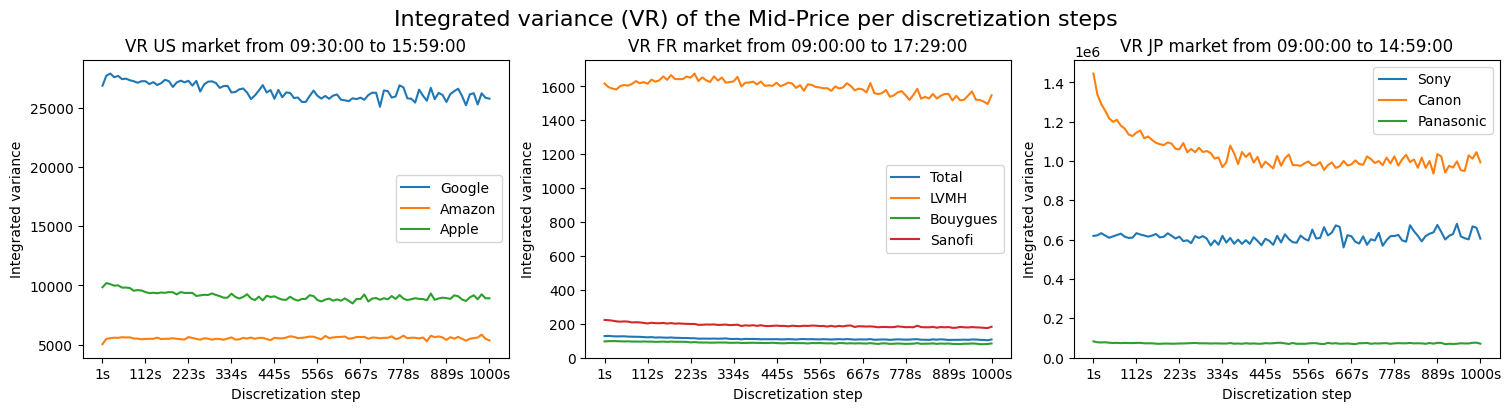

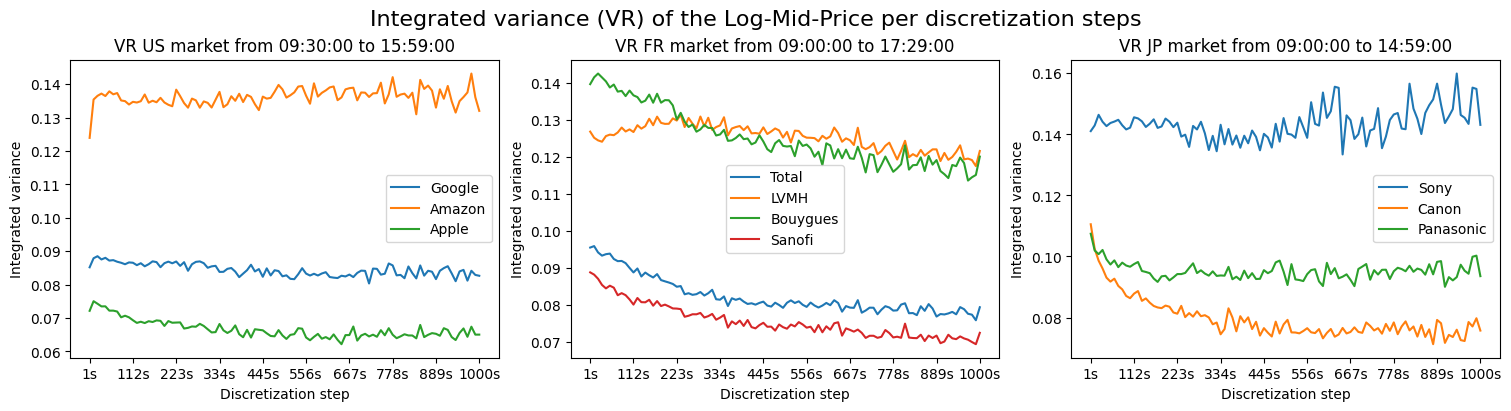

In [8]:
periods = [f"{p}s" for p in np.linspace(1, 1000, num=100, dtype=int)]

min_time_param = ["Opening"]*len(total_list)
max_time_param = ["Closing"]*len(total_list)

plot_volatility(total_list, total_list_name, titles, min_time_param, max_time_param, periods, "Mid-Price","VR")
plot_volatility(total_list, total_list_name, titles, min_time_param, max_time_param, periods, "Log-Mid-Price","VR")

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">Garman and Klass volatility estimator</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

### 2. Intraday Volatility Estimator of Garman and Klass

They consider consider intraday volatility estimators that are based upon the historical opening, closing, high, and low prices and transaction volume. Since high and low prices require continuous monitoring to obtain, they correspondingly contain superior information content, exploited herein.

Their model assumes that a diffusion process governs security prices
$$P_t = \Phi(X_t)$$
where $P$ is the security price, $t$ is time, $\Phi$ is a monotonic, time-independent transformation, and $X_t$ is a diffusion process with the differential representation
$$dX_t = \sigma dW_t$$
where $W_t$ is the standard Brownian motion and $\sigma$ is an unknown constant to be estimated.

**"Best" Analytic Scale-invariant Estimators**

They consider estimators depending on
- the opening price,
- the closing price,
- the high price
- the low price.

For the authors, an estimator is "best" when it has minimum variance and is unbiased. They also impose the requirements that the estimators be analytic with price and time symmetries and scale-invariant. Under regularity condition (analytic in a neighborhood of the
origin), they obtain that the estimator must be quadratic in its arguments. Owing scale invariance and analyticity, they reduce the problem and find the "best" estimator of this form (unbiased with minimum variance). 

Finally, by eliminating the cross-product terms, the recommended and "more practical" estimator reads
$$\sigma_{GK}^2=\frac12\left(\mbox{High}-\mbox{Low}\right)^2-(2\ln2-1)\left(\mbox{Close}-\mbox{Open}\right)^2.$$

<font color='blue'>**To do.** 1. Compute the integrated variance with the Garman-Klass volatility estimator of both mid- and log-mid prices with respect to $\Delta$. Compare the results with the previous one.</font>

### Function

In [9]:
def GK_variance(df, periods, min_time, max_time, type=None, coeff=1): 
    
    """
    Computes the Garman-Klass variance estimator using OHLC prices.

    Parameters
    ----------
    df           : DataFrame
                   Price data with bid/ask columns.
    periods      : list
                   Time intervals for resampling.
    min_time     : str
                   Start of time window.
    max_time     : str
                   End of time window.
    type         : str, optional
                   "Mid-Price" or "Log-Mid-Price" to transform prices.
    coeff        : float, optional
                   Scaling multiplier. Default is 1.

    Returns
    -------
    list         : Realized Garman-Klass variance per period.
    """

    if type == "Mid-Price":  # Check if the selected price type is "Mid-Price"
        price = (df['AskPrice'] + df['BidPrice']) / 2  # Compute the mid-price
    elif type == "Log-Mid-Price":  # Check if the selected price type is "Log-Mid-Price"
        price = np.log((df['AskPrice'] + df['BidPrice']) / 2)  # Compute the log mid-price

    price = price.to_frame(name="price")  # Convert price series to DataFrame with column name "price"
    vols = []  # Initialize list to store variance values

    for period in periods:  # Iterate over each period

        # Resample price data at the given interval and compute OHLC values
        price_resampled = price.resample(period).agg({'price': ['max', 'min', 'first', 'last']}).dropna()

        price_resampled.columns = ['high', 'low', 'open', 'close']  # Rename columns for better readability
        price_resampled = price_resampled.between_time(min_time, max_time)  # Filter data between min_time and max_time

        # Compute the Garman-Klass variance estimator formula
        var = 0.5 * ((price_resampled['high'] - price_resampled['low']) ** 2) - (2 * np.log(2) - 1) * ((price_resampled['close'] - price_resampled['open']) ** 2)

        var_period = var.resample("1D").sum()  # Aggregate variance on a daily basis
        vols.append(var_period.sum() * coeff)  # Scale variance using the coefficient and store in the list

    return vols  # Return the list of Garman-Klass variance values

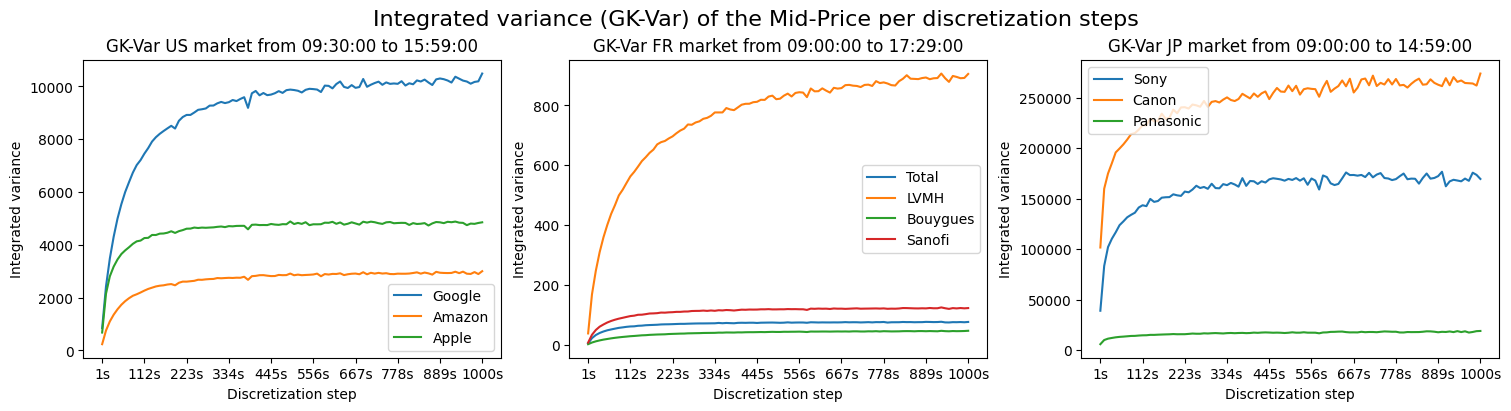

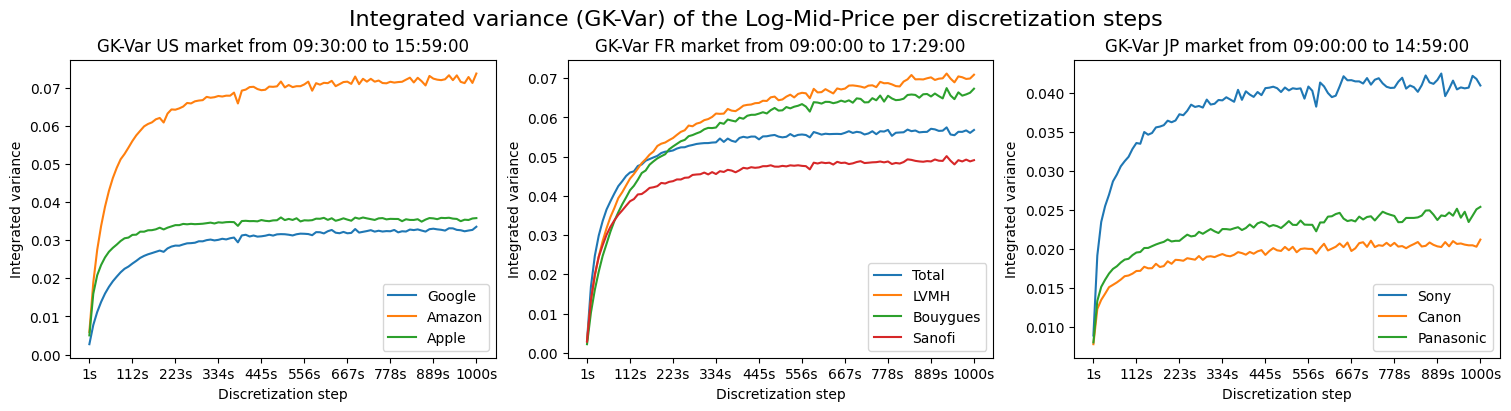

In [10]:
periods = [f"{p}s" for p in np.linspace(1, 1000, num=100, dtype=int)]

min_time_param = ["Opening"]*len(total_list)
max_time_param = ["Closing"]*len(total_list)

plot_volatility(total_list, total_list_name, titles, min_time_param, max_time_param, periods, "Mid-Price","GK-Var")
plot_volatility(total_list, total_list_name, titles, min_time_param, max_time_param, periods, "Log-Mid-Price","GK-Var")

<font color='blue'> 2. Compute the daily volatility with $\sigma_{GK}$ and $\hat{\sigma}$ (the standard deviation of the mid-price and log-mid-price). Compare and comment the results.</font>

### Function

In [11]:
def std_vol(df, periods, min_time, max_time, type=None, coeff=1):  
    """
    Computes the standard deviation of asset prices over different time periods.

    Parameters:
    df (DataFrame): Price data containing bid and ask prices.
    periods (list): Time intervals for variance computation (e.g., "1s", "5s").
    min_time (str): Start time for filtering the data.
    max_time (str): End time for filtering the data.
    type (str, optional): Specifies price calculation method ("Mid-Price" or "Log-Mid-Price").
    coeff (float, optional): Scaling coefficient (default is 1, used for annualization).

    Returns:
    list: Computed standard deviation values for each period.
    """

    if type == "Mid-Price":  # Check if price type is "Mid-Price"
        price = (df['AskPrice'] + df['BidPrice']) / 2  # Compute mid-price
    elif type == "Log-Mid-Price":  # Check if price type is "Log-Mid-Price"
        price = np.log((df['AskPrice'] + df['BidPrice']) / 2)  # Compute log mid-price

    vols = []  # Initialize an empty list to store standard deviation values

    for period in periods:  # Loop through each time period

        price_resampled = price.resample(period).last().dropna()  # Resample and take last price per interval, remove NaN
        price_resampled = price_resampled.between_time(min_time, max_time)  # Filter data between min_time and max_time
        var = np.sum(price_resampled.diff()**2)  # Compute variance as sum of squared differences

        vols.append(np.sqrt(var) * coeff)  # Compute standard deviation and apply scaling coefficient

    return vols  # Return the list of computed standard deviation values

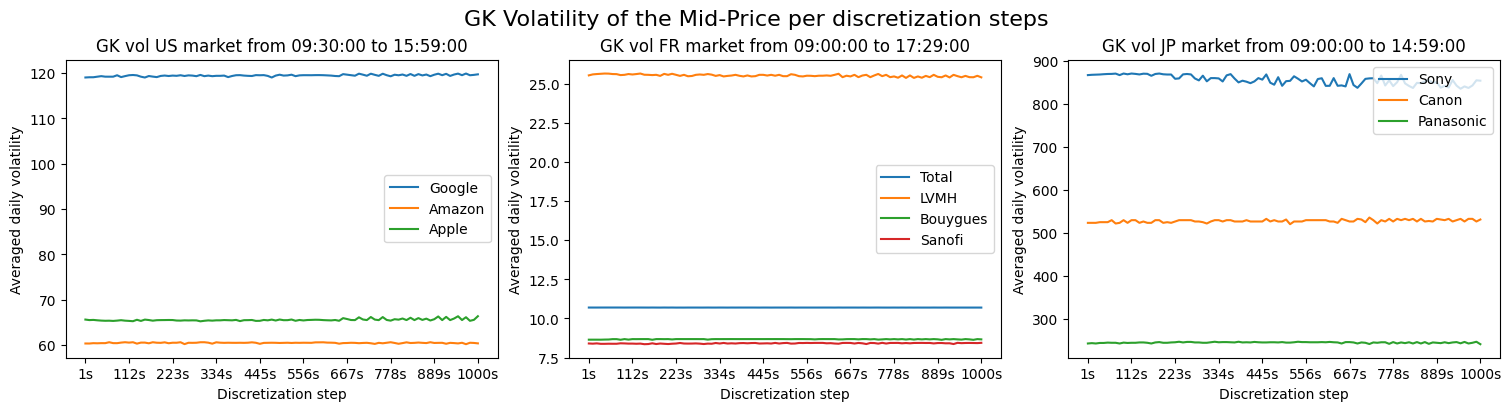

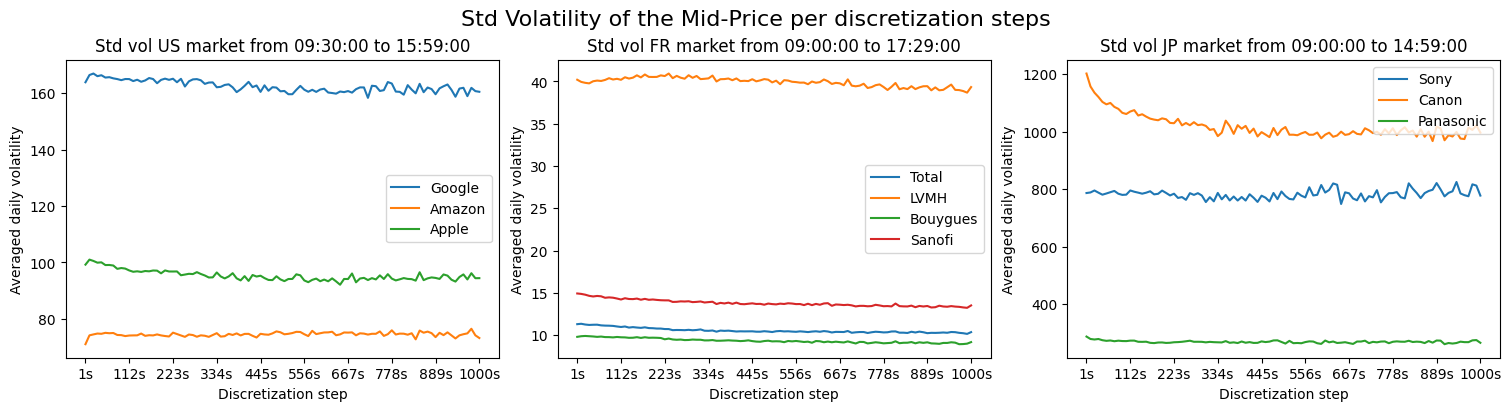

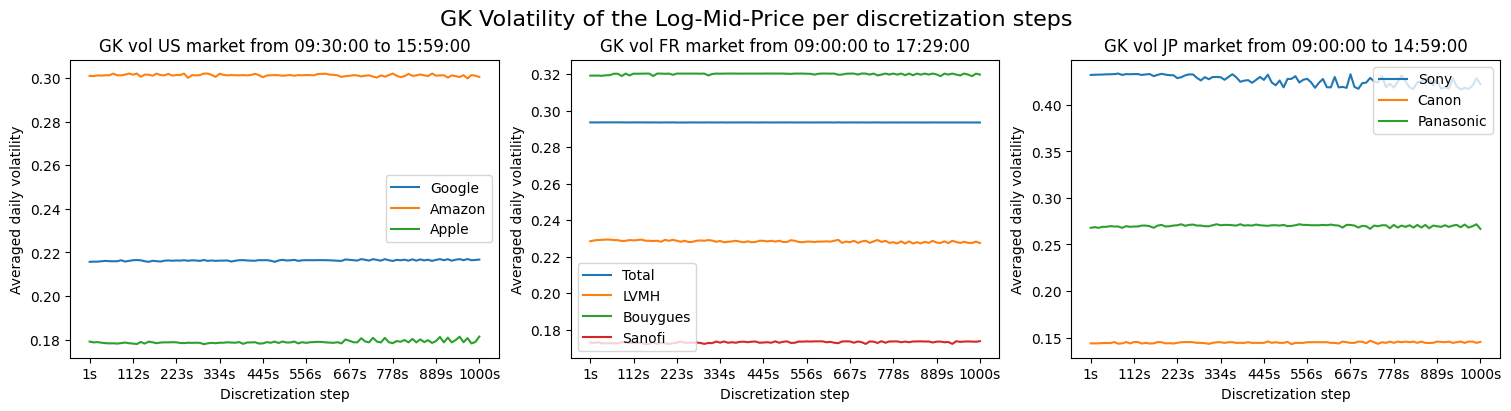

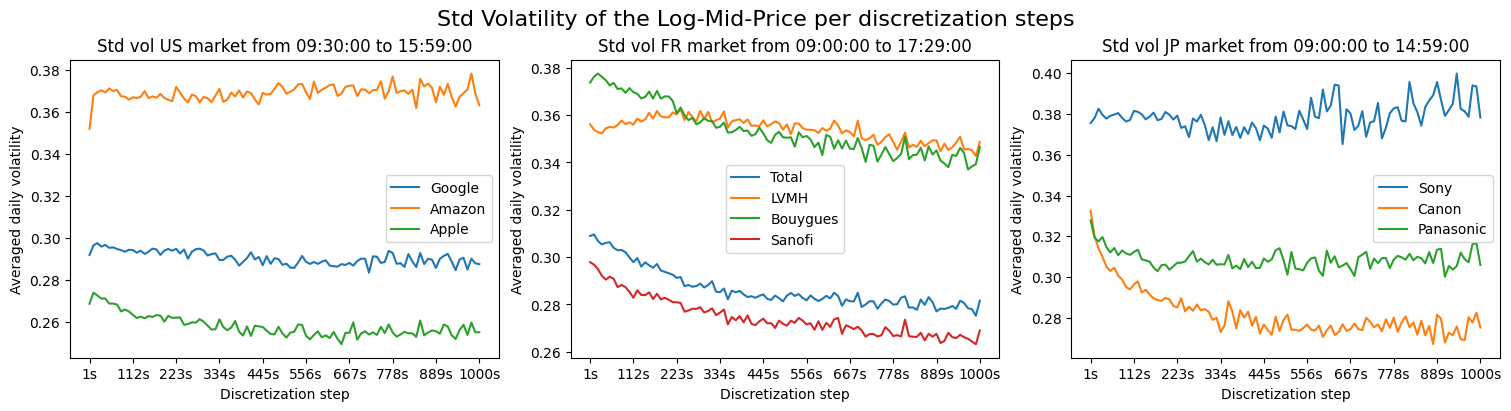

In [12]:
periods = [f"{p}s" for p in np.linspace(1, 1000, num=100, dtype=int)]

min_time_param = ["Opening"]*len(total_list)
max_time_param = ["Closing"]*len(total_list)

plot_volatility(total_list, total_list_name, titles, min_time_param, max_time_param, periods, "Mid-Price","GK")
plot_volatility(total_list, total_list_name, titles, min_time_param, max_time_param, periods, "Mid-Price","Std")
plot_volatility(total_list, total_list_name, titles, min_time_param, max_time_param, periods, "Log-Mid-Price","GK")
plot_volatility(total_list, total_list_name, titles, min_time_param, max_time_param, periods, "Log-Mid-Price","Std")

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">Covariance</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

## II. Covariance Estimator and Epps Effect

### 1. "Classical" Covariance Estimator

Let $X^1= \log P^1$ and $X^2 = \log P^2$ be two log-price processes. 
$$d X^1 = \mu_t^1dt+\sigma_{t-}^1dW^1_t,$$
$$d X^2 = \mu_t^2dt+\sigma_{t-}^2dW^2_t,$$
with $d\left\langle W^1,W^2\right\rangle_t=\rho_tdt$.

Set for every $j\in{1,\ldots,T/\Delta}$, $r^1_{\Delta}(j)=X^1_{\Delta j}-X^1_{\Delta(j-1)}$ and $r^2_{\Delta}(j)=X^2_{\Delta j}-X^2_{\Delta(j-1)}$ the log-price increments.

Then the integrated covariance between the two assets reads
$$\int_0^T\rho_s\sigma^1_s\sigma^2_sds=\lim_{\Delta\to0}\sum_{j=1}^{T/\Delta}r^1_{\Delta}(j)r^2_{\Delta}(j).$$
Thus, an estimator for the realized covariance may be written as 
$$\hat{C}_R(\Delta)=\sum_{j=1}^{T/\Delta}r^1_{\Delta}(j)r^2_{\Delta}(j).$$ 
This estimator is consistent since 
$$\hat{C}_R(\Delta)\overset{\mathbb{P}}{\underset{\Delta\to0}{\longrightarrow}}\int_0^T\rho_s\sigma^1_s\sigma^2_sds.$$ 

The problem is that we must have synchronous data, but the quotations and transactions are asynchronous.

### 2. Previous Tick Estimator

Assume now that we observe $P^1$ at times $(T^1_j)_{j\geq1}$ and $P^2$ at times $(T^2_j)_{j\geq1}$. Therefore we design 
$$\bar{P}^1_t=P_{T^1_j} \quad\mbox{for }t\in[T^1_j,T^1_{j+1})$$
and
$$\bar{P}^2_t=P_{T^2_j} \quad\mbox{for }t\in[T^2_j,T^1_{j+1}).$$
Then 
$$\bar{X}^1_t=\log \bar{P}^1_t \quad\mbox{and}\quad\bar{X}^2_t=\log \bar{P}^2_t/$$

For a given $\Delta$, the previous tick covariation estimator is
$$\bar{C}_R(\Delta)=\sum_{j=1}^{T/\Delta}\left(\bar{X}^1_{\Delta j}-\bar{X}^1_{\Delta (j-1)}\right)\left(\bar{X}^2_{\Delta j}-\bar{X}^2_{\Delta (j-1)}\right).$$

### 3. Epps Effect

Epps (1979): "Correlations among price changes [...] are found to decrease with the length of the interval for which the price changes are measured."
Many explanations were proposed
- systematic bias for this estimator,
- "lead-lag" effect for the assets in the same sector,
- asynchronicity of transactions,
- "tick" effect and other microstructure effects.

**Example.** Assume that $X^1$ and $X^2$ are two Brownian motions with correlation $\rho$ and the trade times are arrival times of two independent Poisson processes. Then, one can show that
$$\mathbb{E}[\bar{C}_R(\Delta)]\underset{\Delta\to0}{\longrightarrow}0.$$

<font color='blue'>**To do.** Plot the correlation with respect to $\Delta$ (in minutes or seconds) for couples of asset on the same exchange (using the mid-price and the log-mid-price). Comment the results.</font>

### Function

In [21]:
def covar(df, periods, min_time, max_time, type=None, coeff=1): 
    
    """
    Computes the covariance between two assets' returns.

    Parameters
    ----------
    df        : list of DataFrame
                Two dataframes with Bid/Ask prices.
    periods   : list
                Time intervals for resampling.
    min_time  : str
                Start of time window.
    max_time  : str
                End of time window.
    type      : str, optional
                "Mid-Price" or "Log-Mid-Price".
    coeff     : float, optional
                Optional scaling factor.

    Returns
    -------
    list      : Covariance values per period.
    """

    # Compute Mid-Price or Log-Mid-Price based on the `type` parameter
    if type == "Mid-Price":  
        price1 = (df[0]['AskPrice'] + df[0]['BidPrice']) / 2  # Mid-price for asset 1
        price2 = (df[1]['AskPrice'] + df[1]['BidPrice']) / 2  # Mid-price for asset 2
    elif type == "Log-Mid-Price":  
        price1 = np.log((df[0]['AskPrice'] + df[0]['BidPrice']) / 2)  # Log mid-price for asset 1
        price2 = np.log((df[1]['AskPrice'] + df[1]['BidPrice']) / 2)  # Log mid-price for asset 2

    covars = []  # List to store computed covariance values

    for period in periods:  # Iterate over each time period
        # Resample and restrict to common times
        res1 = price1.resample(period).last().dropna()
        res2 = price2.resample(period).last().dropna()

        # Keep only common timestamps
        common_idx = res1.index.intersection(res2.index)
        res1 = res1.loc[common_idx]
        res2 = res2.loc[common_idx]

        # Apply time filtering
        res1 = res1.between_time(min_time, max_time)
        res2 = res2.between_time(min_time, max_time)

        # Recheck common timestamps after time filtering
        common_idx = res1.index.intersection(res2.index)
        res1 = res1.loc[common_idx]
        res2 = res2.loc[common_idx]

        # Compute returns
        ret1 = np.diff(res1.to_numpy())
        ret2 = np.diff(res2.to_numpy())

        # Final alignment check
        min_len = min(len(ret1), len(ret2))
        if min_len == 0:
            covars.append(np.nan)
        else:
            covars.append(np.nansum(ret1[:min_len] * ret2[:min_len]))

    return covars  # Return list of computed covariance values

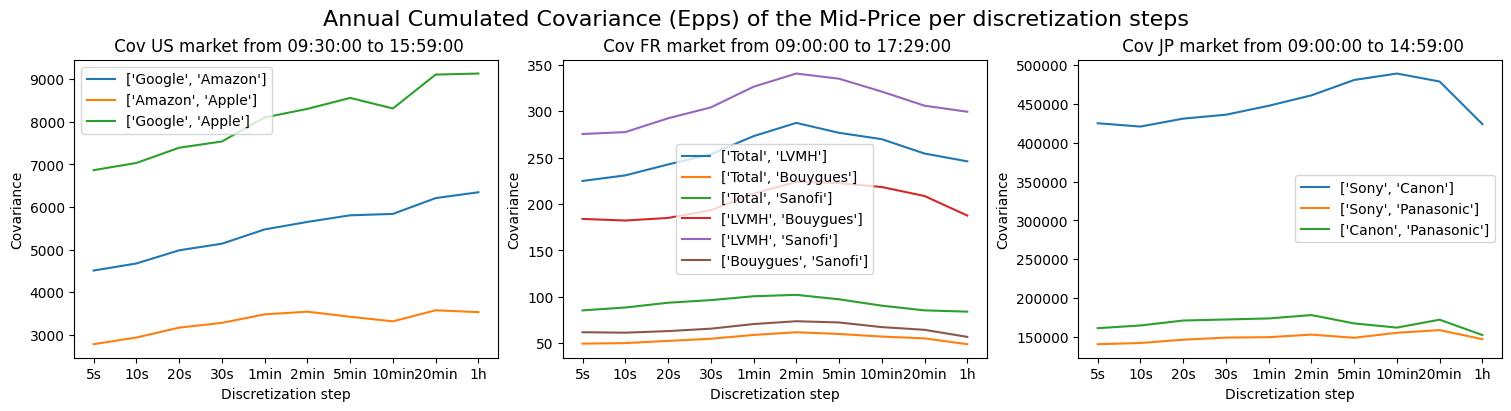

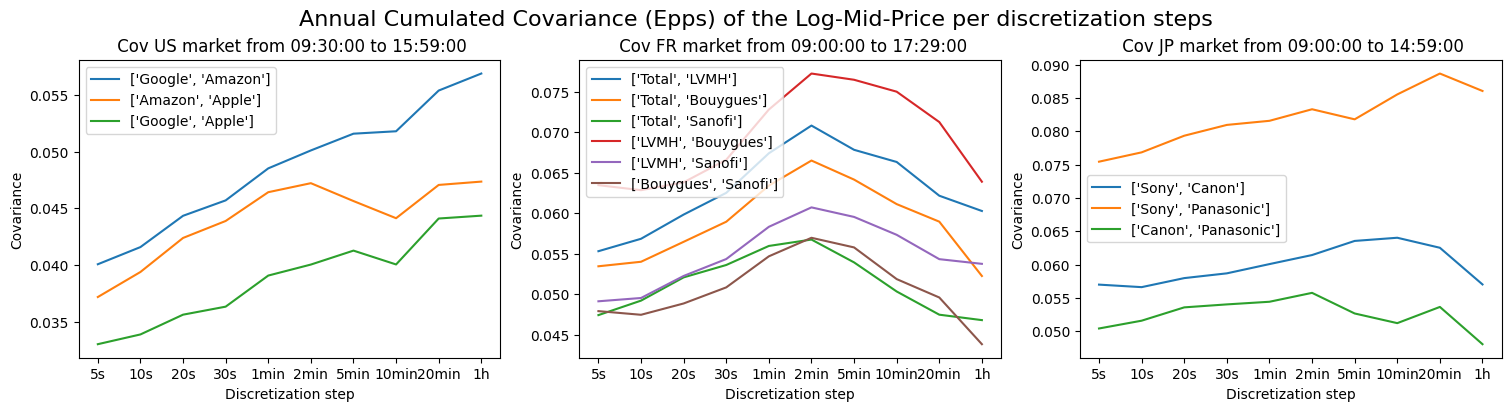

In [22]:
periods = ["5s", "10s","20s","30s","1min","2min","5min","10min","20min","1h"]

min_time_param = ["Opening"]*len(total_list)
max_time_param = ["Closing"]*len(total_list)

plot_volatility(total_list_covar, total_list_covar_name, titles, min_time_param, max_time_param, periods, "Mid-Price","Covar")
plot_volatility(total_list_covar, total_list_covar_name, titles, min_time_param, max_time_param, periods, "Log-Mid-Price","Covar")

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">Hayashi-Yoshida estimator</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

The correlation estimator for high-frequency data is studied in many publications, for example Hayashi & Yoshida or Zhang.

### 4. Hayashi-Yoshida Estimator

Let $I^1_i=(T^1_i,T^1_{i+1}]$, $i\geq1$, and $I^2_j=(T^2_j,T^2_{j+1}]$, $j\geq1$.

The cumulative covariance estimator of Hayashi-Yoshida reads
$$U_n=\sum_{i,j}\Delta P^1(I^1_i)\Delta P^2(I^2_j)\mathbb{1}_{\{I^1_i\cap I^2_j\neq\emptyset\}}.$$

That is, the product of any pair of increments $\Delta P^1(I^1_i)$ and $\Delta P^2(I^2_j)$ will make a contribution to the summation only when the respective observation intervals $I^1_i$ and $I^2_i$ are overlapping.

This estimator does not need any selection of $\Delta$ and is convergent if the arrival times are independent from the price.

Then, they define two associated correlation estimators
- if $\sigma_1$ and $\sigma_2$ are known,
$$R^1_n=\frac1T\frac{\sum_{i,j}\Delta P^1(I^1_i)\Delta P^2(I^2_j)\mathbb{1}_{\{I^1_i\cap I^2_j\neq\emptyset\}}}{\sigma_1\sigma_2},$$
- if $\sigma_1$ and $\sigma_2$ are known/unknown,
$$R^2_n=\frac{\sum_{i,j}\Delta P^1(I^1_i)\Delta P^2(I^2_j)\mathbb{1}_{\{I^1_i\cap I^2_j\neq\emptyset\}}}{\sqrt{\sum_i\Delta P^1(I^1_i)^2}\sqrt{\sum_j\Delta P^2(I^2_j)^2}}.$$
Under the same conditions as for $U_n$, $R^1$ and $R^2$ are consistent for $\rho$ as $n\to\infty$.

**Remark.** This estimator is nevertheless not robust to microstructure effects.

<font color='blue'>**To do.** Compute the daily Hayashi-Yoshida estimator for couples of assets on the same exchange and compare it to classical estimator. Do it for one month you choose and plot the results. Comment. </font>

### Function

In [23]:
def HY(df, price_type, month_days): 
    
    """
    Computes the Hayashi-Yoshida estimator for asynchronous time series.

    Parameters
    ----------
    df           : list of DataFrame
                   Contains two asset price DataFrames.
    price_type   : str
                   "Mid-Price" or "Log-Mid-Price".
    month_days   : list
                   List of days to compute the estimator over.

    Returns
    -------
    HY_list      : list
                   Computed HY covariances (normalized) for each day.
    """

    df1 = df[0]  # First asset price dataframe
    df2 = df[1]  # Second asset price dataframe
    HY_list = []  # List to store HY covariance values

    for day_filter in month_days:  # Iterate through each day
        day_filter = pd.to_datetime(day_filter)  # Convert to datetime format

        df1_filtered = df1[df1.index.normalize() == day_filter]  # Filter df1 for the specific day
        df2_filtered = df2[df2.index.normalize() == day_filter]  # Filter df2 for the specific day

        if df1_filtered.empty or df2_filtered.empty:  # Check if any dataframe is empty
            HY_list.append(np.nan)  # Append NaN if no data
            continue 

        # Compute mid-price or log-mid-price based on `price_type`
        if price_type == "Mid-Price":  
            price1 = (df1_filtered['AskPrice'] + df1_filtered['BidPrice']) / 2  
            price2 = (df2_filtered['AskPrice'] + df2_filtered['BidPrice']) / 2  
        elif price_type == "Log-Mid-Price":  
            price1 = np.log((df1_filtered['AskPrice'] + df1_filtered['BidPrice']) / 2)  
            price2 = np.log((df2_filtered['AskPrice'] + df2_filtered['BidPrice']) / 2)  
        else:
            raise ValueError(f"Type de prix '{price_type}' non reconnu.")  # Raise error for incorrect price type

        # Compute price differences
        price1_diff = price1.diff().dropna()  
        price2_diff = price2.diff().dropna()  

        # Compute standard deviations (volatility) of price changes
        sigma1 = np.sqrt(np.sum(price1_diff ** 2))  
        sigma2 = np.sqrt(np.sum(price2_diff ** 2))  
        
        if sigma1 == 0 or sigma2 == 0:  # Check if standard deviation is zero
            HY_list.append(np.nan)  
            continue

        # Initialize variables for covariance computation
        i, j = 0, 0  
        U_n = 0  

        prices1 = price1_diff.values  # Extract values of price1 differences
        prices2 = price2_diff.values  # Extract values of price2 differences

        times_1 = price1_diff.index  # Extract timestamps for price1
        times_2 = price2_diff.index  # Extract timestamps for price2

        # Iterate over both series to calculate overlapping periods
        while i < len(price1_diff) and j < len(price2_diff):
            T1_start, T1_end = times_1[i], times_1[i + 1] if i + 1 < len(price1_diff) else times_1[i]  
            T2_start, T2_end = times_2[j], times_2[j + 1] if j + 1 < len(price2_diff) else times_2[j]  

            if max(T1_start, T2_start) < min(T1_end, T2_end):  # Check if time intervals overlap
                U_n += prices1[i] * prices2[j]  # Compute contribution to covariance

            if T1_end < T2_end:  # Move index for the asset with the earlier timestamp
                i += 1
            else:
                j += 1

        # Compute normalized HY covariance and store it
        HY_list.append(U_n / (sigma1 * sigma2))  

    return HY_list  # Return computed HY covariance values

def HY_estimator(datas_list, names, titles, month_days, month, price_type="Mid-Price"): 
    
    """
    Computes and plots the Hayashi-Yoshida covariance estimator.

    Parameters
    ----------
    datas_list  : list of list of DataFrame
                  Each item contains two DataFrames for a pair of assets.
    names       : list
                  Labels for each asset pair.
    titles      : list
                  Title to display for each subplot.
    month_days  : list
                  Days over which to compute the estimator.
    month       : str
                  Month to annotate in the plot title.
    price_type  : str, optional
                  Either "Mid-Price" or "Log-Mid-Price".

    Returns
    -------
    None       : Displays plots.
    """

    num_datasets = len(datas_list)  # Get the number of datasets
    fig, axes = plt.subplots(1, num_datasets, figsize=(5 * num_datasets, 8), constrained_layout=True)  # Create subplot grid
    
    if num_datasets == 1:
        axes = [axes]  # Convert to list if only one dataset
    
    for dataset_idx, datas in enumerate(datas_list):  # Loop over datasets
        ax = axes[dataset_idx]  # Select corresponding subplot

        # Compute HY estimator using multi-threading
        with ThreadPoolExecutor(max_workers=8) as executor:
            futures = [executor.submit(HY, df, price_type, month_days) for df in datas]  
            etas_and_vols = [f.result() for f in futures]  # Collect results
        
        # Plot results for each asset pair
        for idx in range(len(datas)):  
            ax.plot(range(len(month_days)), etas_and_vols[idx], label=f"{names[dataset_idx][idx]}")  

        ax.set_title(f"Hayashi-Yoshida Estimator {titles[dataset_idx]}")  # Set subplot title
        ax.set_xlabel("Number of days")  # X-axis label
        ax.set_xticks(np.linspace(0, len(month_days) - 1, num=6, dtype=int))  # Set X-axis ticks
        ax.set_ylabel("HY estimator")  # Y-axis label
        ax.legend()  # Add legend
        ax.grid(False)  # Disable grid

    plt.suptitle(f"Hayashi-Yoshida Covariance Estimator for {month}", fontsize=16)  # Add global title
    plt.show()  # Show plot

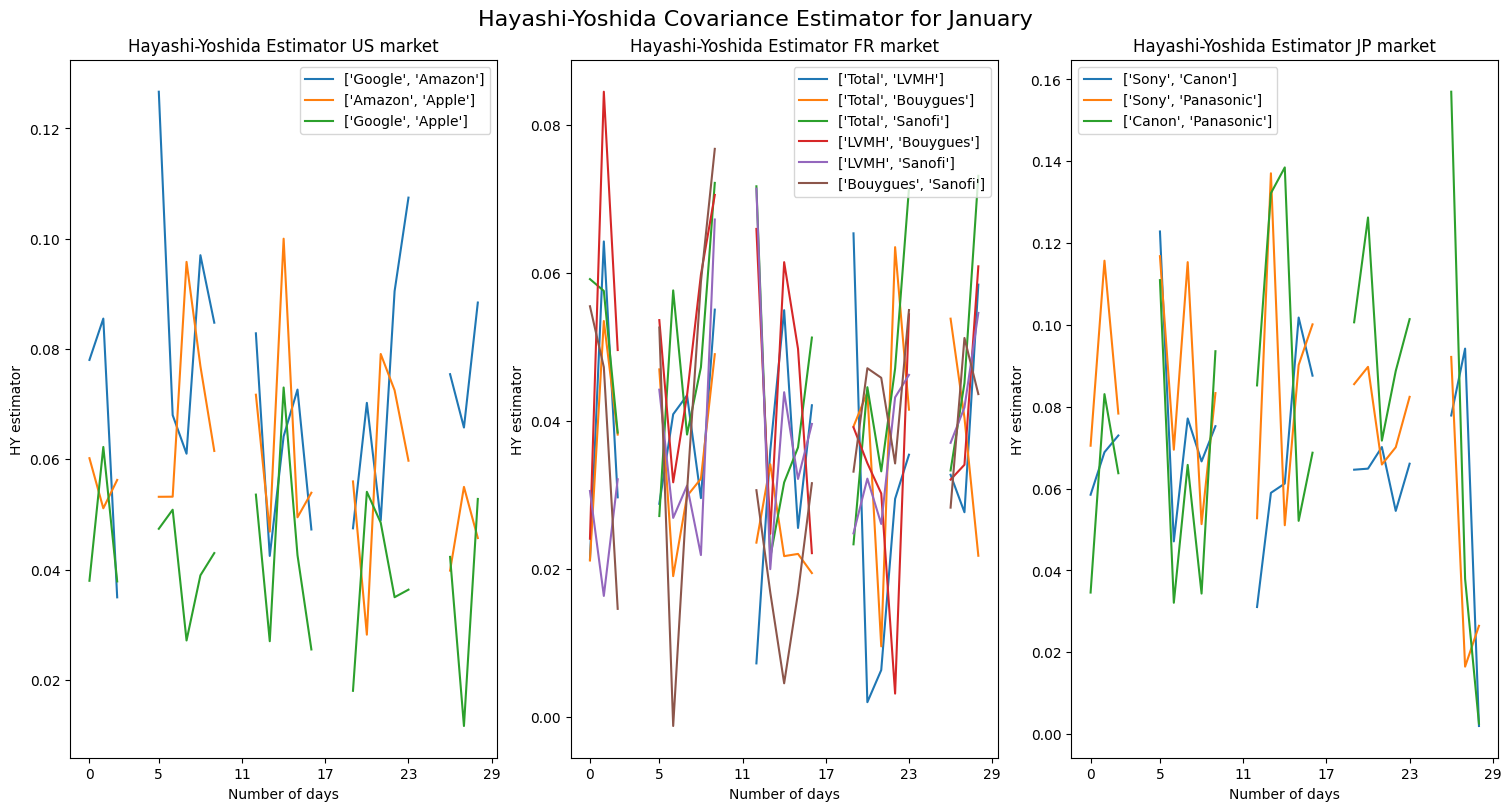

In [24]:
month_days = pd.date_range(start="2011-06-01", end="2011-06-30").strftime("%Y-%m-%d").tolist()
HY_estimator(total_list_covar, total_list_covar_name, titles, month_days, "January",price_type="Mid-Price")

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> Bid-Ask spread and volatility per trade for large tick assets</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

## III. Link between bid-ask spread and volatility per trade for large tick assets

Dayri and Rosenbaum developed a new approach to exhibit the relationship between bid-ask spread and volatility per trade for large tick assets. The model derives from the one with uncertainty zones. They assume the existence of a {\em latent price} representing the opinion of market participants on the ``true'' price and modeled by a continuous Brownian semi-martingale $(x_t)_{t\geq0}$. Let $\alpha$ be the tick size of the asset. The areas of uncertainty are defined as bands around the middle of the tick size with width $2\eta\alpha$, $0<\eta<1$. The dynamics of the price of the last transaction $p_t$ is obtained as a function of the latent price and areas of uncertainty. The bid-ask spread is assumed to be constant and equal to the tick size $\alpha$. 

The authors define alternating (resp. continuity) of a tick size as a jump in the price of a tick size whose direction is adverse (resp. the same) than the previous jump. The number of alternations and continuities of a tick size are denoted by $N_{\alpha,t}^{(a)}$ and $N_{\alpha,t}^{(c)}$ respectively on the period $[0,t]$. The consistent estimator of $\eta$ on $[0,t]$ is then
$$\widehat{\eta}_{\alpha,t}=\frac{N_{\alpha,t}^{(c)}}{2N_{\alpha,t}^{(a)}}.$$
For volatility, first note that this model allows to find the value of the latent price on the date of $\tau_i$ of the $i^{th}$ price change by the simple relationship
$$x_{\tau_i}=p_{\tau_i}-\mbox{sign}\left(p_{\tau_i}-p_{\tau_{i-1}}\right)\left(\frac12-\eta\right)\alpha.$$
As we can estimate $\eta$, we can then find out $x_{\tau_i}$ from $p_{\tau_{i-1}}$ and $p_{\tau_i}$. For example, the realized variance on estimated values of the efficient price on $[0,t]$
$$\widehat{\sigma^2_{LP,t}}=\sum_{\tau_i\leq t}\left(\widehat{x}_{\tau_i}-\widehat{x}_{\tau_{i-1}}\right)^2,$$
where $\widehat{x}_{\tau_i}=p_{\tau_i}-\mbox{sign}\left(p_{\tau_i}-p_{\tau_{i-1}}\right)\left(\frac12-\widehat{\eta}_{\alpha,t}\right)\alpha$, is an estimator of the integrated variance of the latent price over $[0,t]$ $\int_0^t\sigma_s^2ds$. Now we set $\widehat{\sigma}_{LP}=\sqrt{\widehat{\sigma^2_{[0,t]}}}$ and we define the volatility per trade by $\widehat{\sigma}_{LP}/\sqrt{N}$ where $N:=N_{[0,t]}$ denotes the total number of trades on $[0,t]$. Without making any differences between parameters and their estimates, we get then the following relationship
\begin{equation}\label{EtaLP}
\eta\alpha\approx c\frac{\sigma_{LP}}{\sqrt{N}}.
\end{equation}
Market participants have a certain resolution, or precision at which they infer the efficient price $x_t$. $\eta$ quantifies this resolution: when $\eta$ is close to 1/2, the resolution is close to the tick value. The quantity $2\eta\alpha$ can be seen as an implicit spread: $\eta$ can indeed be viewed as a suitable measure for the tick size.


<font color='blue'>**To do.** 1. Compute $\eta$, $\alpha$ and $\sigma_{LP}$ on a daily basis for each asset. Compare the implicit spread and the real spread. Idem for the volatilities of both latent price and traded price. Comment.</font>

<font color='blue'> 2. Implement the linear regression for large tick asset and compare to the results of the previous practical work.</font>

### Function

In [27]:
def eta_alpha_vol(df, Vol_Compair, Spread, Regression): 
    
    """
    Computes various volatility metrics and price impact measures.

    Parameters
    ----------
    df          : DataFrame
                  Data containing traded prices, bid/ask quotes, etc.
    Vol_Compair : bool
                  If True, compare Traded Price vs Latent Price volatilities.
    Spread      : bool
                  If True, compute implied vs actual bid-ask spread.
    Regression  : bool
                  If True, prepare data for implicit spread regression.

    Returns
    -------
    list        : List of computed metrics depending on the chosen mode.
    """

    daily_df_list = [group for _, group in df.groupby(df.index.date)]  # Group data by day
    etas = []
    sigmas = []
    alpha = (df['BidPrice'] - df['AskPrice']).abs().min()  # Smallest absolute spread
    sigmas_LP = []
    sigmas_TP = []
    impli_spread = []
    true_spread = []
    Ns = []
    eta_alpha = []
    
    for daily_df in daily_df_list:  # Iterate through daily data
        
        diff = daily_df['TradedPrice'].diff()  # Compute price differences
        diff_shifted = daily_df['TradedPrice'].diff().shift(1)  # Shifted differences for comparison
        continuation = (diff * diff_shifted).apply(lambda x: 1 if x > 0 else 0).sum()  # Count continuations
        alteration = (diff * diff_shifted).apply(lambda x: 1 if x <= 0 else 0).sum()  # Count alterations
        eta = continuation / (2 * alteration)  # Compute eta
        diff_sign = diff.apply(lambda x: -1 if x < 0 else 1)  # Get trade direction
        
        if Vol_Compair:  # Compare volatilities
            sigma_component_LP = daily_df['TradedPrice'].shift(1).dropna() - diff_sign * (0.5 - eta) * alpha
            sigma_LP = (sigma_component_LP.diff()**2).sum()
            sigma_component_TP = daily_df['TradedPrice']
            sigma_TP = (sigma_component_TP.diff()**2).sum()
            sigmas_TP.append(np.sqrt(sigma_TP))
            sigmas_LP.append(np.sqrt(sigma_LP))
            
        elif Spread:  # Compute spreads
            impli_spread.append(2 * eta * alpha)
            true_spread.append((daily_df['AskPrice'] - daily_df["BidPrice"]).mean())
        
        elif Regression:  # Prepare data for regression
            eta_alpha.append(eta * alpha)
            Ns.append(len(daily_df))
            sigma_component_LP = daily_df['TradedPrice'].shift(1).dropna() - diff_sign * (0.5 - eta) * alpha
            sigma_LP = (sigma_component_LP.diff()**2).sum()
            sigmas_LP.append(np.sqrt(sigma_LP))
            
        else:  # Default case: Compute eta and volatility
            sigma_component = daily_df['TradedPrice'].shift(1).dropna() - diff_sign * (0.5 - eta) * alpha
            sigma = (sigma_component.diff()**2).sum()
            etas.append(eta)
            sigmas.append(np.sqrt(sigma))
            
    # Return computed values based on the mode
    if Vol_Compair:
        return [sigmas_TP, sigmas_LP]
    elif Spread:
        return [impli_spread, true_spread]
    elif Regression:
        vol_trades = np.array(sigmas_LP) * np.sqrt(np.array(Ns))
        return [eta_alpha, vol_trades]
    else:
        return [etas, sigmas]

def plot_eta_vol(datas, names, titles, Vol_Compair=False, Spread=False, Regression=False): 
    
    """
    Plots price impact measures, volatility profiles, or spread structures.

    Parameters
    ----------
    datas       : list
                  List of lists of DataFrames (grouped per dataset).
    names       : list
                  Asset labels for the plot legends.
    titles      : list
                  Descriptive titles per dataset.
    Vol_Compair : bool
                  If True, compares Latent vs Traded Price volatility.
    Spread      : bool
                  If True, plots implied and realized spreads.
    Regression  : bool
                  If True, fits and plots regression of ηα vs σ.

    Returns
    -------
    None        : Displays plots.
    """

    num_datasets = len(datas)  # Number of datasets
    if Vol_Compair or Spread or Regression:  
        fig, axes = plt.subplots(1, num_datasets, figsize=(5 * num_datasets, 8), constrained_layout=True)  # Single row layout
    else:  
        fig, axes = plt.subplots(2, num_datasets, figsize=(5 * num_datasets, 8), constrained_layout=True)  # Two-row layout
        if num_datasets == 1:
            axes = np.array([[axes[0]], [axes[1]]])

    for idx_data, data in enumerate(datas): 
        
        reference_df = data[0]  
        reference_df['Date'] = reference_df.index.date  # Extract dates
        unique_days = sorted(reference_df['Date'].unique())  # Unique days

        # Compute eta and volatility using multi-threading
        with ThreadPoolExecutor(max_workers=8) as executor:
            etas_and_vols = list(executor.map(eta_alpha_vol, data, [Vol_Compair]*len(data), [Spread]*len(data), [Regression]*len(data)))
            
        if Vol_Compair:  
            for idx in range(len(data)): 
                ax = axes if num_datasets == 1 else axes[idx_data]                                
                ax.plot(range(len(unique_days)), etas_and_vols[idx][0], label=f"Latent Price Vol {names[idx_data][idx]}")
                ax.plot(range(len(unique_days)), etas_and_vols[idx][1], label=f"Traded Price Vol {names[idx_data][idx]}")
                ax.set_title(f"Realized Vol {titles[idx_data]}")
                ax.set_xlabel("Time")
                ax.set_ylabel("Volatility")
                ax.legend()
                ax.grid(False)
            plt.suptitle("Daily realized vol Latent Price and Traded Price", fontsize=16)
                
        elif Spread:  
            for idx in range(len(data)): 
                ax = axes if num_datasets == 1 else axes[idx_data]                                
                ax.plot(range(len(unique_days)), etas_and_vols[idx][0], label=f"Implied spread {names[idx_data][idx]}")
                ax.plot(range(len(unique_days)), etas_and_vols[idx][1], label=f"Avg day spread {names[idx_data][idx]}")
                ax.set_title(f"Spreads {titles[idx_data]}")
                ax.set_xlabel("Time")
                ax.set_ylabel("Spread")
                ax.legend()
                ax.grid(False)
            plt.suptitle("Daily Implicit and Explicit spread", fontsize=16)
            
        elif Regression:  
            for idx in range(len(data)): 
                ax = axes if num_datasets == 1 else axes[idx_data]                
                X = np.array(etas_and_vols[idx][1]).reshape(-1, 1)
                Y = np.array(etas_and_vols[idx][0])
                model = LinearRegression()
                model.fit(X, Y)
                X_range = np.linspace(0, X.max(), 100).reshape(-1, 1)
                Y_pred = model.predict(X_range)
                slope = model.coef_[0]
                ax.scatter(X, Y, label=f"{names[idx_data][idx]}", marker=".", alpha=0.3)
                ax.plot(X_range, Y_pred, label=f"{names[idx_data][idx]} Regression: $y = {slope:.3f}x$")
                ax.set_title(f"Lin Reg Impli-Spread/Trades-Adjust Latent Vol {titles[idx_data]}")
                ax.set_xlabel("eta*alpha")
                ax.set_ylabel("Spread")
                ax.legend()
                ax.grid(False)

        else:  # Default case for plotting eta and volatility
            for idx in range(len(data)): 
                ax_eta = axes[0, idx_data]
                ax_vol = axes[1, idx_data]
                ax_eta.plot(range(len(unique_days)), etas_and_vols[idx][0], label=f"{names[idx_data][idx]}")
                ax_vol.plot(range(len(unique_days)), etas_and_vols[idx][1], label=f"{names[idx_data][idx]}")
                ax_eta.set_title(f"Daily Eta for {titles[idx_data]}")
                ax_vol.set_title(f"Daily implied vol -Traded Price- {titles[idx_data]}")
                ax_eta.set_xlabel("Time")
                ax_vol.set_xlabel("Time")
                ax_eta.set_ylabel("Eta")
                ax_vol.set_ylabel("Volatility")
                ax_eta.legend()
                ax_vol.legend()
                ax_eta.grid(False)
                ax_vol.grid(False)
            plt.suptitle("Daily Eta and Volatility Analysis", fontsize=16)
        
    plt.show()

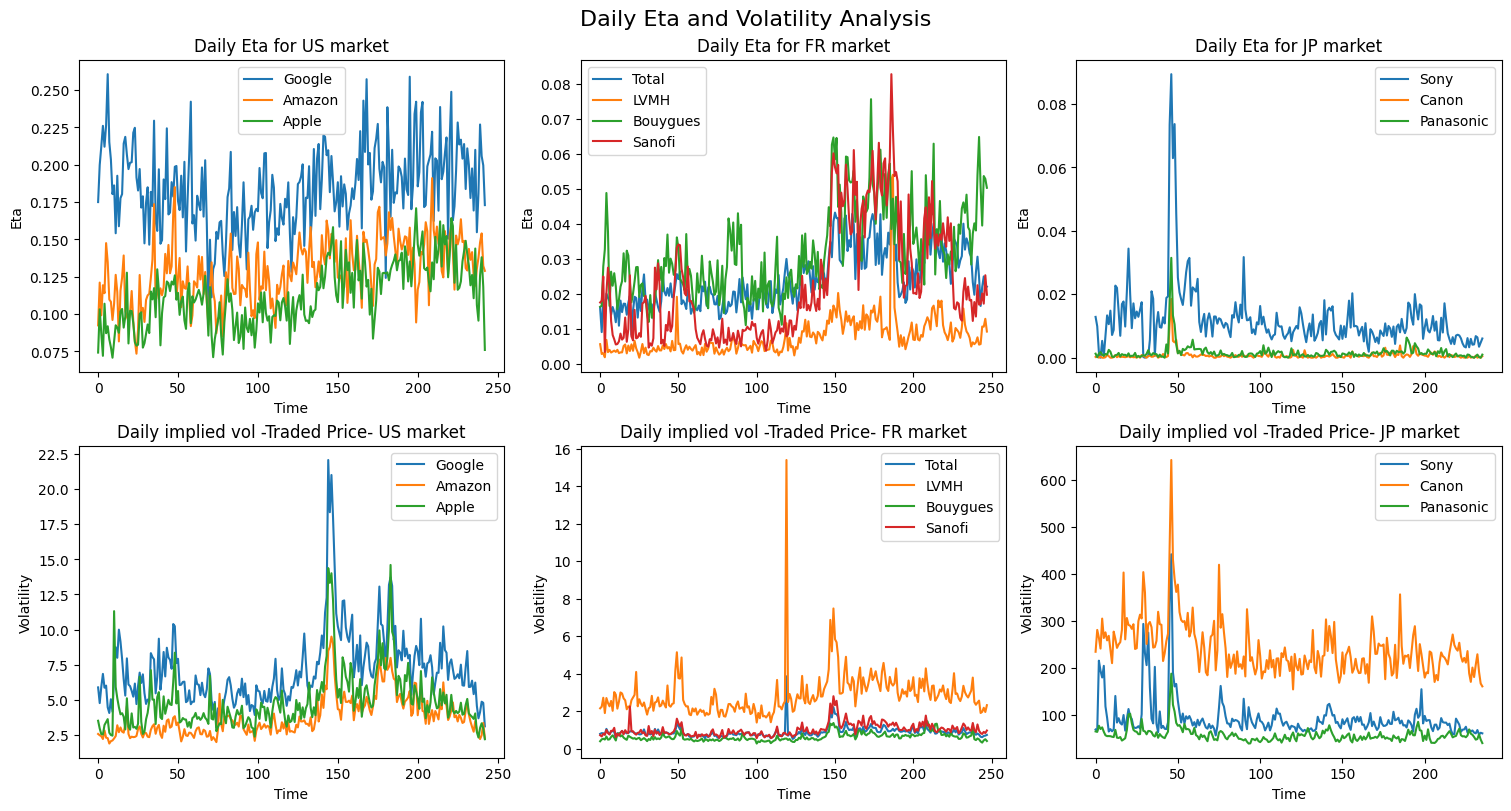

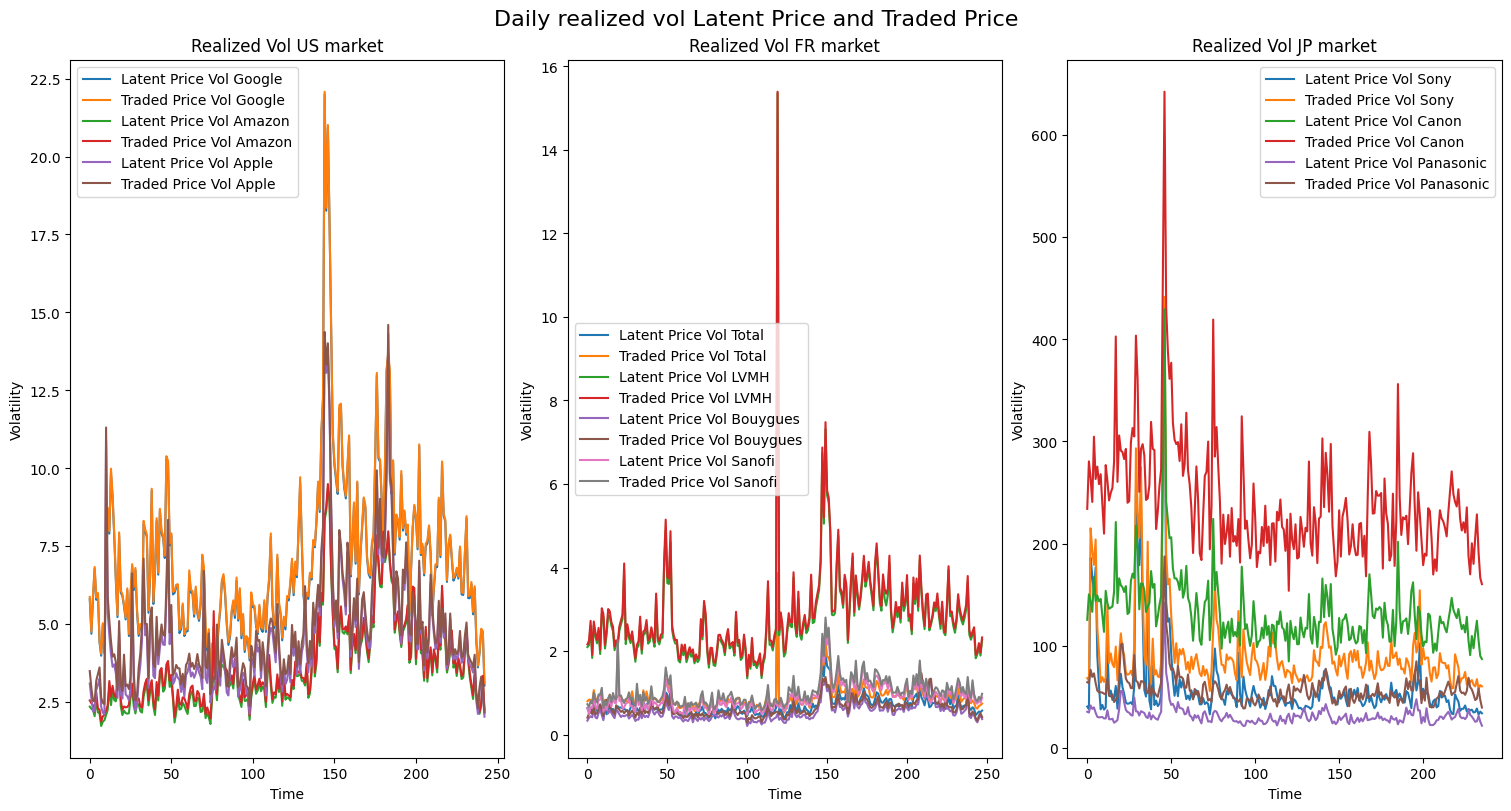

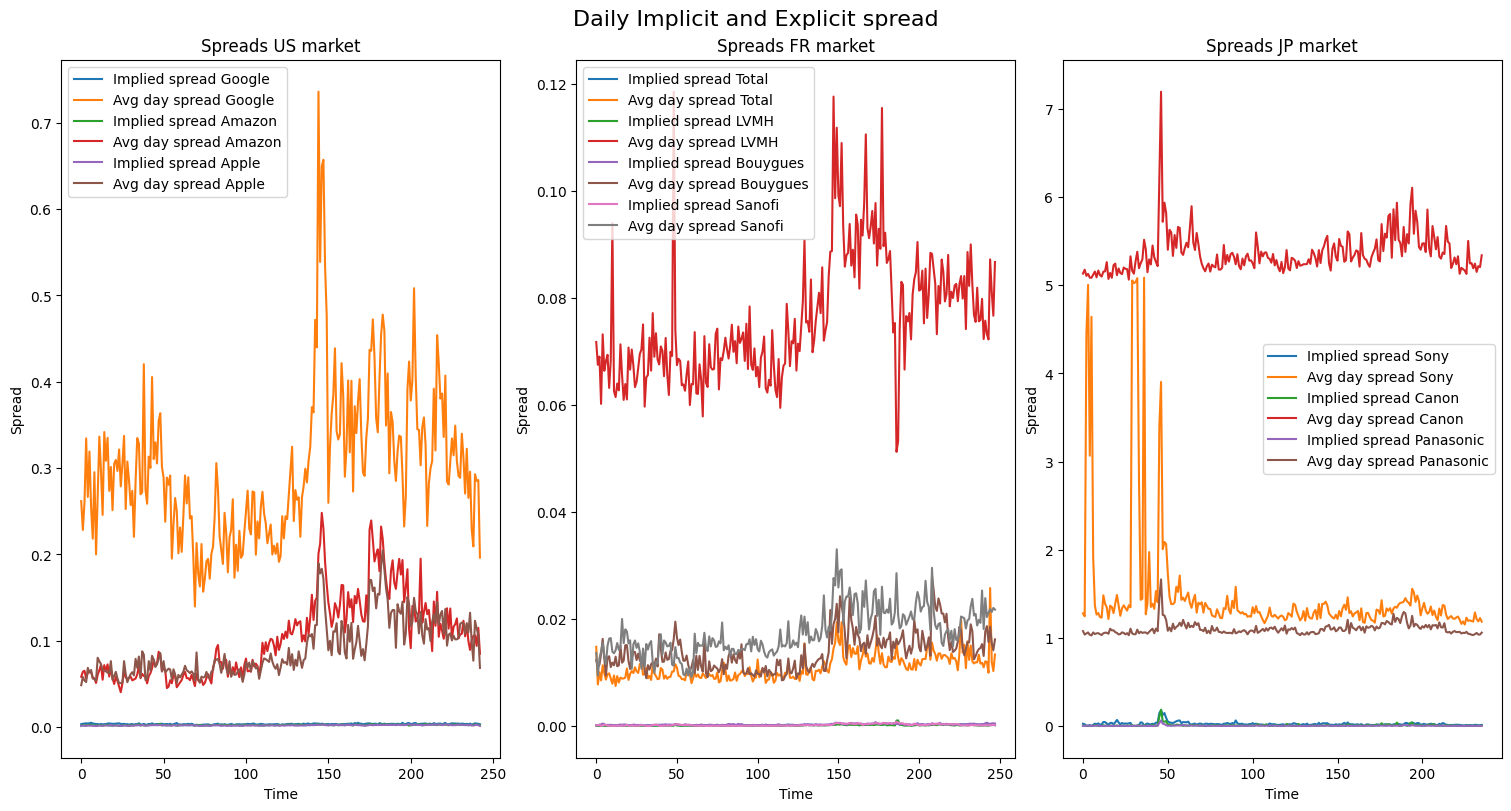

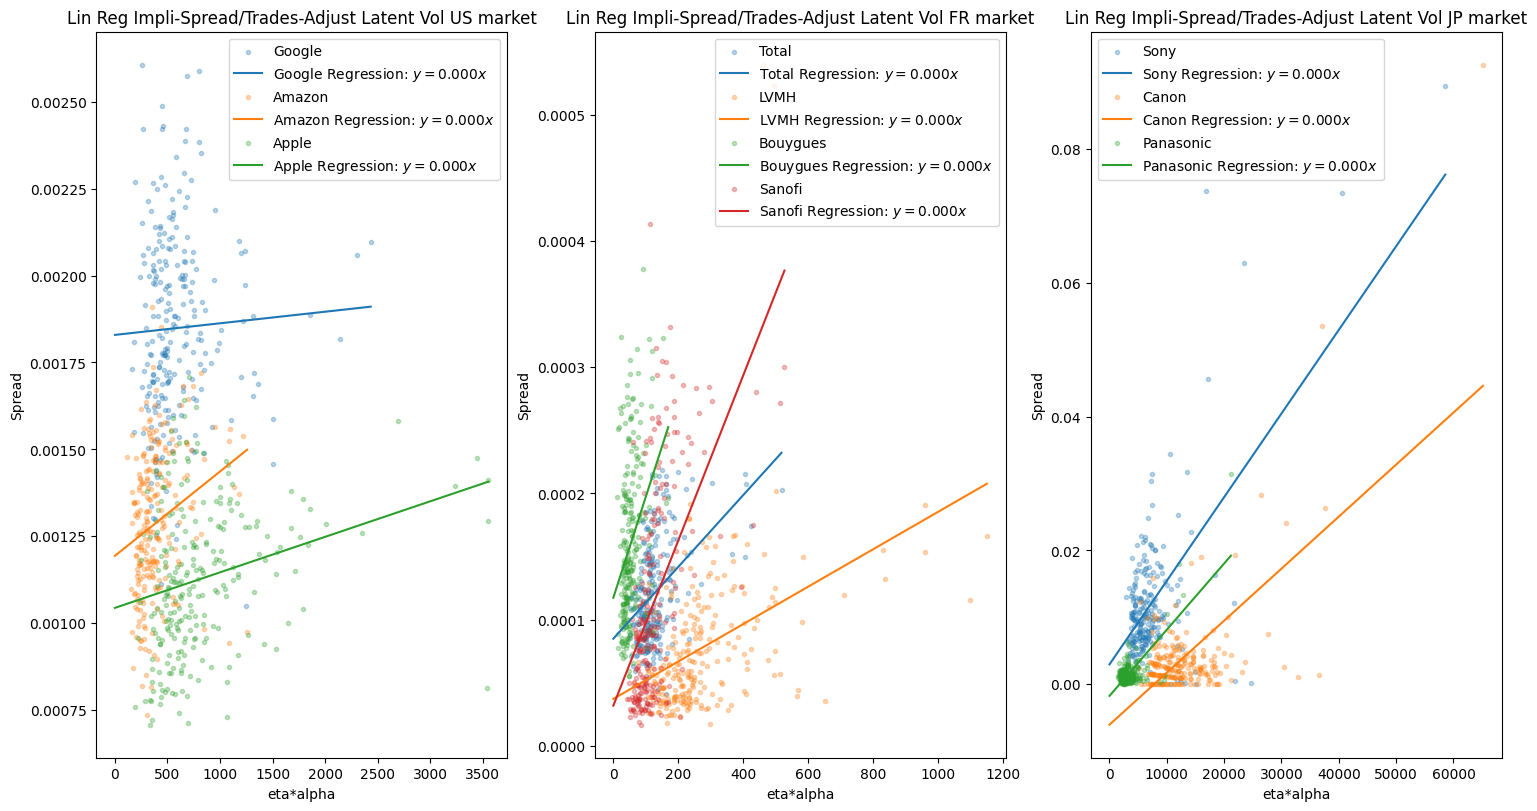

In [28]:
plot_eta_vol(total_list, total_list_name, titles,Vol_Compair = False, Spread = False)
plot_eta_vol(total_list, total_list_name, titles,Vol_Compair = True)
plot_eta_vol(total_list, total_list_name, titles,Vol_Compair = False, Spread = True)
plot_eta_vol(total_list, total_list_name, titles,Vol_Compair = False, Spread = False, Regression = True)